<a href="https://colab.research.google.com/github/OvoFiona/Fraud-Detection/blob/main/FraudDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Import Libraries and loading dataset
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset from the uploaded CSV file
print("Please upload the 'bank_transaction_data_2.csv' file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

Please upload the 'bank_transaction_data_2.csv' file:


Saving bank_transactions_data_2.csv to bank_transactions_data_2.csv


In [2]:
#Displaying basic information about the dataset
print("="*50)
print("BASIC DATASET INFORMATION")
print("="*50)
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
print(df.head())

BASIC DATASET INFORMATION
Dataset shape: (2512, 16)
Number of rows: 2512
Number of columns: 16

Column names:
['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']

Data types:
TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object

First 5 rows:
  Transaction

DATA CLEANING

MISSING VALUES CHECK
                         Missing Values  Percentage
TransactionID                         0         0.0
AccountID                             0         0.0
TransactionAmount                     0         0.0
TransactionDate                       0         0.0
TransactionType                       0         0.0
Location                              0         0.0
DeviceID                              0         0.0
IP Address                            0         0.0
MerchantID                            0         0.0
Channel                               0         0.0
CustomerAge                           0         0.0
CustomerOccupation                    0         0.0
TransactionDuration                   0         0.0
LoginAttempts                         0         0.0
AccountBalance                        0         0.0
PreviousTransactionDate               0         0.0


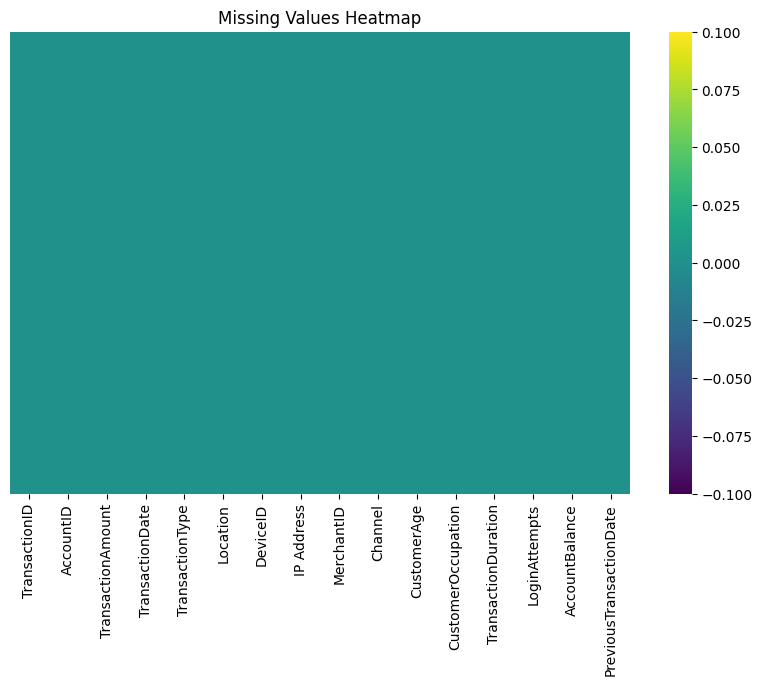

In [3]:
#Check for missing values
print("="*50)
print("MISSING VALUES CHECK")
print("="*50)
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})
print(missing_df)

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [5]:
#Check for duplicate rows
print("="*50)
print("DUPLICATE ROWS CHECK")
print("="*50)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

#Check for duplicate transactions
duplicate_transactions = df.duplicated(subset=['TransactionID']).sum()
print(f"Duplicate Transaction IDs: {duplicate_transactions}")

#If duplicates exist, remove them
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")

DUPLICATE ROWS CHECK
Number of duplicate rows: 0
Duplicate Transaction IDs: 0


In [7]:
#Data type conversion and validation
print("="*50)
print("DATA TYPE VALIDATION")
print("="*50)

# Check current data types
print("Current data types:")
print(df.dtypes)

# Convert date columns to datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

# Calculate time difference between transactions
df['DaysSinceLastTransaction'] = (df['TransactionDate'] - df['PreviousTransactionDate']).dt.total_seconds() / (24 * 3600)
print(f"Time range between transactions: {df['DaysSinceLastTransaction'].min():.2f} to {df['DaysSinceLastTransaction'].max():.2f} days")

print("\nUpdated data types:")
print(df.dtypes)

DATA TYPE VALIDATION
Current data types:
TransactionID                       object
AccountID                           object
TransactionAmount                  float64
TransactionDate             datetime64[ns]
TransactionType                     object
Location                            object
DeviceID                            object
IP Address                          object
MerchantID                          object
Channel                             object
CustomerAge                          int64
CustomerOccupation                  object
TransactionDuration                  int64
LoginAttempts                        int64
AccountBalance                     float64
PreviousTransactionDate     datetime64[ns]
DaysSinceLastTransaction           float64
dtype: object
Time range between transactions: -671.67 to -307.57 days

Updated data types:
TransactionID                       object
AccountID                           object
TransactionAmount                  float64
Transac

In [8]:
#Check for Outliers
print("="*50)
print("OUTLIER DETECTION")
print("="*50)

#Select numerical columns for outlier detection
numerical_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
                  'LoginAttempts', 'AccountBalance', 'DaysSinceLastTransaction']

#Using IQR method to detect outliers
outlier_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = {
        'Total Outliers': len(outliers),
        'Percentage': (len(outliers) / len(df)) * 100
    }

outlier_df = pd.DataFrame(outlier_summary).T
print(outlier_df)

OUTLIER DETECTION
                          Total Outliers  Percentage
TransactionAmount                  113.0    4.498408
CustomerAge                          0.0    0.000000
TransactionDuration                  0.0    0.000000
LoginAttempts                      122.0    4.856688
AccountBalance                       0.0    0.000000
DaysSinceLastTransaction             0.0    0.000000


In [9]:
#Check Value Ranges and Validity
print("="*50)
print("VALUE RANGE VALIDATION")
print("="*50)

# Check for negative amounts
negative_amounts = df[df['TransactionAmount'] < 0].shape[0]
print(f"Transactions with negative amount: {negative_amounts}")

# Check for zero amounts
zero_amounts = df[df['TransactionAmount'] == 0].shape[0]
print(f"Transactions with zero amount: {zero_amounts}")

# Check for negative account balance
negative_balance = df[df['AccountBalance'] < 0].shape[0]
print(f"Accounts with negative balance: {negative_balance}")

# Check for invalid ages
invalid_age = df[(df['CustomerAge'] < 18) | (df['CustomerAge'] > 100)].shape[0]
print(f"Customers with invalid age: {invalid_age}")

VALUE RANGE VALIDATION
Transactions with negative amount: 0
Transactions with zero amount: 0
Accounts with negative balance: 0
Customers with invalid age: 0


In [11]:
#Create derived features for fraud detection
print("="*50)
print("CREATING DERIVED FEATURES")
print("="*50)

# Extract temporal features
df['TransactionHour'] = df['TransactionDate'].dt.hour
df['TransactionDay'] = df['TransactionDate'].dt.day
df['TransactionMonth'] = df['TransactionDate'].dt.month
df['TransactionYear'] = df['TransactionDate'].dt.year
df['TransactionDayOfWeek'] = df['TransactionDate'].dt.dayofweek
df['IsWeekend'] = df['TransactionDayOfWeek'].isin([5, 6]).astype(int)

# Transaction patterns
df['BalanceAfterTransaction'] = df.apply(
    lambda row: row['AccountBalance'] - row['TransactionAmount'] if row['TransactionType'] == 'Debit'
    else row['AccountBalance'] + row['TransactionAmount'], axis=1
)

# Check if balance goes negative after transaction
df['WouldOverdraw'] = (df['BalanceAfterTransaction'] < 0).astype(int)

# Transaction velocity (using rolling window - simplified for demo)
df['HighLoginAttempts'] = (df['LoginAttempts'] > 3).astype(int)

print(f"New features created: TransactionHour, TransactionDay, TransactionMonth, TransactionYear, TransactionDayOfWeek, IsWeekend, BalanceAfterTransaction, WouldOverdraw, HighLoginAttempts")

CREATING DERIVED FEATURES
New features created: TransactionHour, TransactionDay, TransactionMonth, TransactionYear, TransactionDayOfWeek, IsWeekend, BalanceAfterTransaction, WouldOverdraw, HighLoginAttempts


In [12]:
#Clean the data
print("="*50)
print("DATA CLEANING ACTIONS")
print("="*50)

# Remove negative amounts if any (should be none based on check)
df = df[df['TransactionAmount'] >= 0]

# Cap extreme outliers for TransactionAmount (99th percentile)
amount_99th = df['TransactionAmount'].quantile(0.99)
df['TransactionAmount_Capped'] = df['TransactionAmount'].clip(upper=amount_99th)

# Cap extreme LoginAttempts (99th percentile)
login_99th = df['LoginAttempts'].quantile(0.99)
df['LoginAttempts_Capped'] = df['LoginAttempts'].clip(upper=login_99th)

print(f"TransactionAmount capped at 99th percentile: ${amount_99th:.2f}")
print(f"LoginAttempts capped at 99th percentile: {login_99th:.0f}")

# Final cleaned dataset shape
print(f"\nFinal Cleaned Dataset Shape: {df.shape}")

DATA CLEANING ACTIONS
TransactionAmount capped at 99th percentile: $1360.60
LoginAttempts capped at 99th percentile: 5

Final Cleaned Dataset Shape: (2512, 28)


EDA

EXPLORATORY DATA ANALYSIS


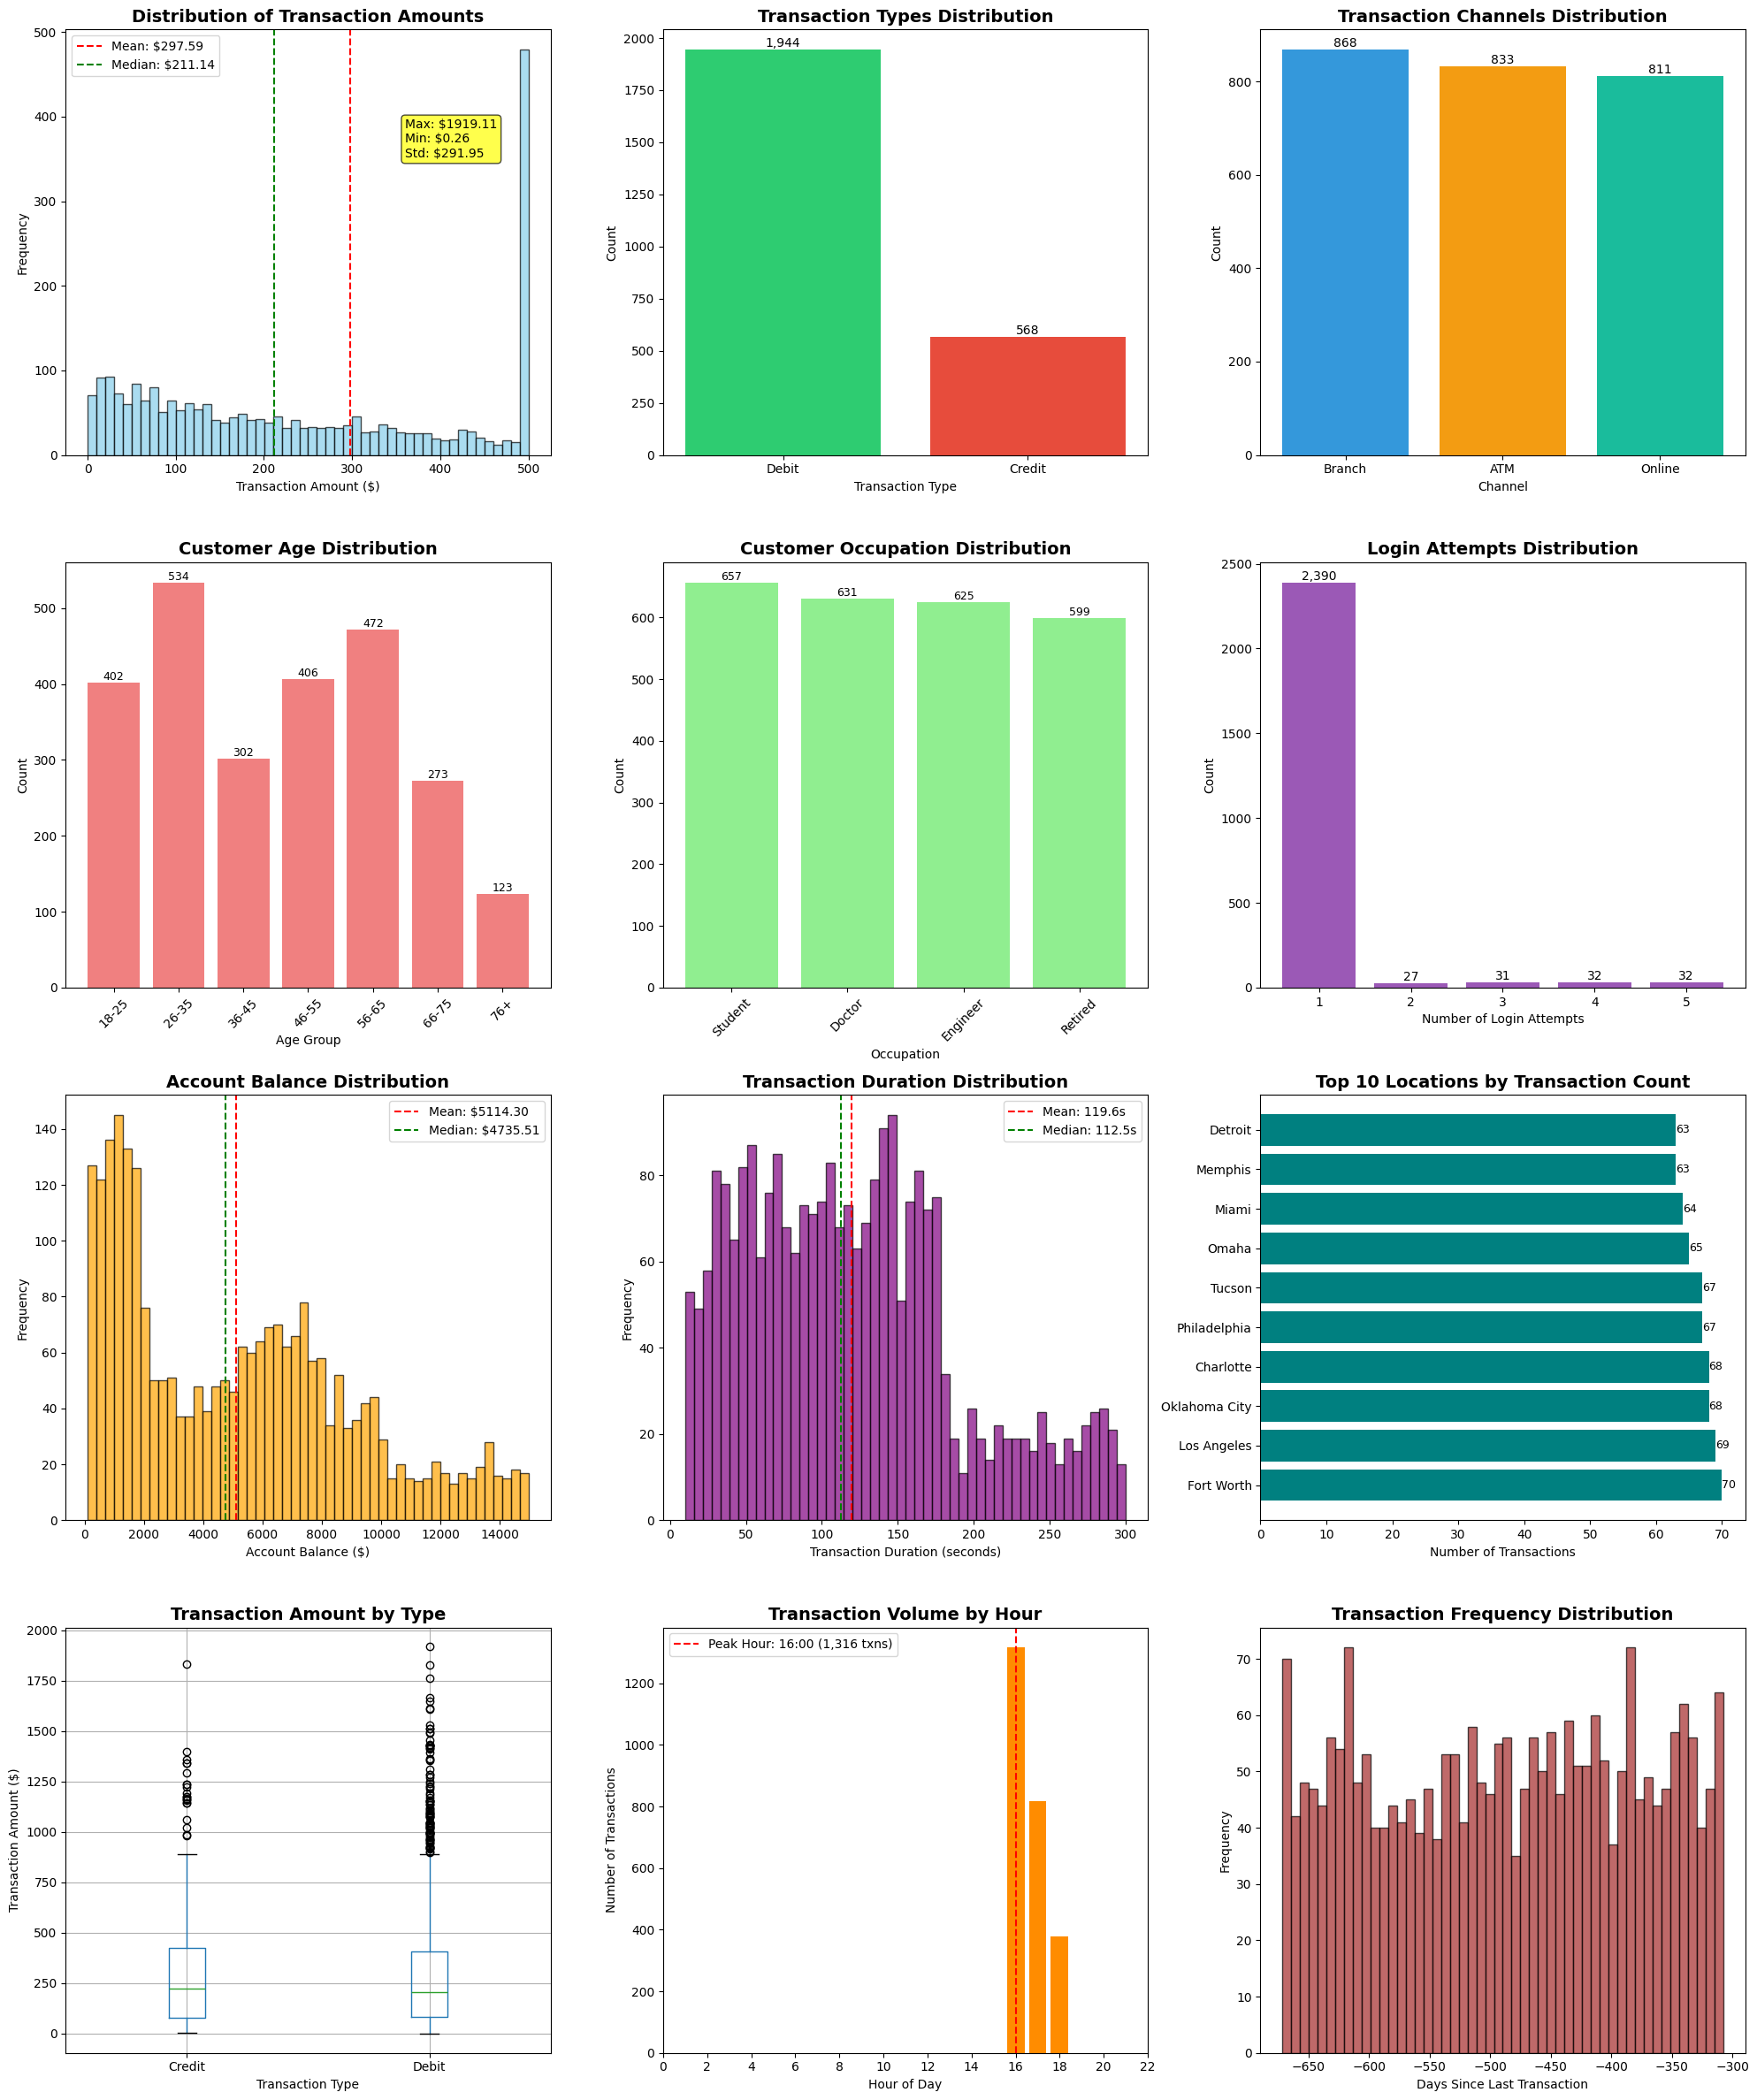

In [13]:
# Section 2: EXPLORATORY DATA ANALYSIS
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# Create a figure with multiple subplots for comprehensive EDA
fig = plt.figure(figsize=(20, 24))

#Transaction Amount Distribution
ax1 = plt.subplot(4, 3, 1)
amount_data = df['TransactionAmount'].clip(upper=500)  # Clip for better visualization
ax1.hist(amount_data, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax1.set_xlabel('Transaction Amount ($)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Transaction Amounts', fontsize=14, fontweight='bold')
ax1.axvline(df['TransactionAmount'].mean(), color='red', linestyle='--',
            label=f"Mean: ${df['TransactionAmount'].mean():.2f}")
ax1.axvline(df['TransactionAmount'].median(), color='green', linestyle='--',
            label=f"Median: ${df['TransactionAmount'].median():.2f}")
ax1.legend()

# Add text box with statistics
stats_text = f"Max: ${df['TransactionAmount'].max():.2f}\nMin: ${df['TransactionAmount'].min():.2f}\nStd: ${df['TransactionAmount'].std():.2f}"
ax1.text(0.7, 0.7, stats_text, transform=ax1.transAxes, bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

#Transaction Type Distribution
ax2 = plt.subplot(4, 3, 2)
tx_type_counts = df['TransactionType'].value_counts()
bars = ax2.bar(tx_type_counts.index, tx_type_counts.values, color=['#2ecc71', '#e74c3c'])
ax2.set_xlabel('Transaction Type')
ax2.set_ylabel('Count')
ax2.set_title('Transaction Types Distribution', fontsize=14, fontweight='bold')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

#Channel Distribution
ax3 = plt.subplot(4, 3, 3)
channel_counts = df['Channel'].value_counts()
bars = ax3.bar(channel_counts.index, channel_counts.values, color=['#3498db', '#f39c12', '#1abc9c'])
ax3.set_xlabel('Channel')
ax3.set_ylabel('Count')
ax3.set_title('Transaction Channels Distribution', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

#Customer Age Distribution
ax4 = plt.subplot(4, 3, 4)
age_bins = [18, 25, 35, 45, 55, 65, 75, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75', '76+']
df['AgeGroup'] = pd.cut(df['CustomerAge'], bins=age_bins, labels=age_labels, right=False)
age_group_counts = df['AgeGroup'].value_counts().sort_index()
bars = ax4.bar(age_group_counts.index, age_group_counts.values, color='lightcoral')
ax4.set_xlabel('Age Group')
ax4.set_ylabel('Count')
ax4.set_title('Customer Age Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

#Occupation Distribution
ax5 = plt.subplot(4, 3, 5)
occupation_counts = df['CustomerOccupation'].value_counts()
bars = ax5.bar(occupation_counts.index, occupation_counts.values, color='lightgreen')
ax5.set_xlabel('Occupation')
ax5.set_ylabel('Count')
ax5.set_title('Customer Occupation Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

#Login Attempts Analysis
ax6 = plt.subplot(4, 3, 6)
login_counts = df['LoginAttempts'].value_counts().sort_index()
bars = ax6.bar(login_counts.index.astype(str), login_counts.values, color='#9b59b6')
ax6.set_xlabel('Number of Login Attempts')
ax6.set_ylabel('Count')
ax6.set_title('Login Attempts Distribution', fontsize=14, fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

#Account Balance Distribution
ax7 = plt.subplot(4, 3, 7)
balance_data = df['AccountBalance'].clip(upper=15000)  # Clip for better visualization
ax7.hist(balance_data, bins=50, edgecolor='black', alpha=0.7, color='orange')
ax7.set_xlabel('Account Balance ($)')
ax7.set_ylabel('Frequency')
ax7.set_title('Account Balance Distribution', fontsize=14, fontweight='bold')
ax7.axvline(df['AccountBalance'].mean(), color='red', linestyle='--',
            label=f"Mean: ${df['AccountBalance'].mean():.2f}")
ax7.axvline(df['AccountBalance'].median(), color='green', linestyle='--',
            label=f"Median: ${df['AccountBalance'].median():.2f}")
ax7.legend()

#Transaction Duration Analysis
ax8 = plt.subplot(4, 3, 8)
ax8.hist(df['TransactionDuration'], bins=50, edgecolor='black', alpha=0.7, color='purple')
ax8.set_xlabel('Transaction Duration (seconds)')
ax8.set_ylabel('Frequency')
ax8.set_title('Transaction Duration Distribution', fontsize=14, fontweight='bold')
ax8.axvline(df['TransactionDuration'].mean(), color='red', linestyle='--',
            label=f"Mean: {df['TransactionDuration'].mean():.1f}s")
ax8.axvline(df['TransactionDuration'].median(), color='green', linestyle='--',
            label=f"Median: {df['TransactionDuration'].median():.1f}s")
ax8.legend()

#Top 10 Locations by Transaction Count
ax9 = plt.subplot(4, 3, 9)
top_locations = df['Location'].value_counts().head(10)
bars = ax9.barh(range(len(top_locations)), top_locations.values, color='teal')
ax9.set_yticks(range(len(top_locations)))
ax9.set_yticklabels(top_locations.index)
ax9.set_xlabel('Number of Transactions')
ax9.set_title('Top 10 Locations by Transaction Count', fontsize=14, fontweight='bold')

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax9.text(width, bar.get_y() + bar.get_height()/2., f'{int(width):,}',
             ha='left', va='center', fontsize=9)

#Transaction Amount by Type
ax10 = plt.subplot(4, 3, 10)
df.boxplot(column='TransactionAmount', by='TransactionType', ax=ax10)
ax10.set_title('Transaction Amount by Type', fontsize=14, fontweight='bold')
ax10.set_xlabel('Transaction Type')
ax10.set_ylabel('Transaction Amount ($)')
plt.suptitle('')  # Remove automatic suptitle

#Transaction Hour Distribution
ax11 = plt.subplot(4, 3, 11)
hour_counts = df['TransactionHour'].value_counts().sort_index()
bars = ax11.bar(hour_counts.index, hour_counts.values, color='darkorange')
ax11.set_xlabel('Hour of Day')
ax11.set_ylabel('Number of Transactions')
ax11.set_title('Transaction Volume by Hour', fontsize=14, fontweight='bold')
ax11.set_xticks(range(0, 24, 2))

#Highlight peak hours
peak_hour = hour_counts.idxmax()
ax11.axvline(peak_hour, color='red', linestyle='--',
             label=f"Peak Hour: {peak_hour}:00 ({hour_counts.max():,} txns)")
ax11.legend()

#Days Since Last Transaction Distribution
ax12 = plt.subplot(4, 3, 12)
days_data = df['DaysSinceLastTransaction'].clip(upper=100)
ax12.hist(days_data, bins=50, edgecolor='black', alpha=0.7, color='brown')
ax12.set_xlabel('Days Since Last Transaction')
ax12.set_ylabel('Frequency')
ax12.set_title('Transaction Frequency Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('transaction_eda_overview.png', dpi=300, bbox_inches='tight')
plt.show()